In [15]:
import pandas as pd

titanic_df = pd.read_csv("update_titanic_data.csv")

len(titanic_df)

889

## Handling Outliers

### 1. Using IQR

https://www.researchgate.net/publication/340996565/figure/fig3/AS:962186885210119@1606414638167/Box-plot-and-probability-density-function-of-a-normal-distribution.png

<Axes: >

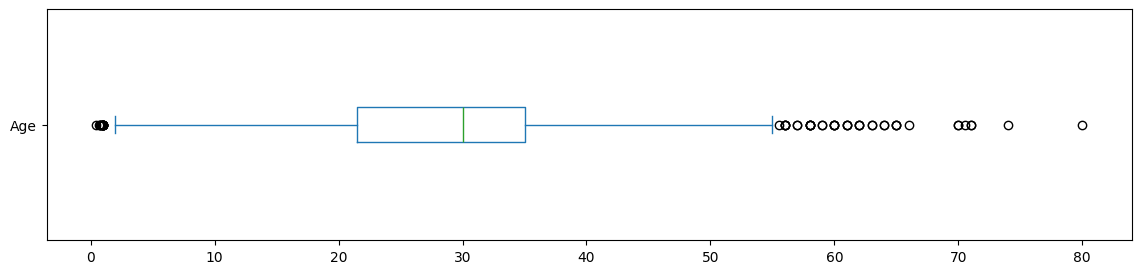

In [6]:
titanic_df.Age.plot(kind="box", vert = False, figsize=(14,3))

In [19]:
q1 = titanic_df.Age.quantile(q = 0.25)
q3 = titanic_df.Age.quantile(q = 0.75)

IQR = q3 - q1

maximum = q3 + ( 1.5 * IQR )
minimum = q1 - ( 1.5 * IQR )


In [20]:
outliers = titanic_df[(titanic_df.Age > maximum) | (titanic_df.Age < minimum)]
outliers.head()

,Survived,initials,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,PStatus
11,1,Miss,"Bonnell, Miss. Elizabeth",female,58.00,0.0,0.0,113783,26.5500,True,S,1
33,0,Mr,"Wheadon, Mr. Edward H",male,66.00,0.0,0.0,C.A. 24579,10.5000,False,S,2
54,0,Mr,"Ostby, Mr. Engelhart Cornelius",male,65.00,0.0,1.0,113509,61.9792,True,C,1
77,1,Master,"Caldwell, Master. Alden Gates",male,0.83,0.0,2.0,248738,29.0000,False,S,2
93,0,Mr,"Coxon, Mr. Daniel",male,59.00,0.0,0.0,364500,7.2500,False,S,3


In [21]:
outliers.shape

(53, 12)

In [ ]:
# Try using Clip function

tiatnic_no_outliers_df = titanic_df[(titanic_df.Age <= maximum) & (titanic_df.Age >= minimum)]

tiatnic_no_outliers_df.head()

,Survived,initials,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,PStatus
0,0,Mr,"Braund, Mr. Owen Harris",male,22.0,1.0,0.0,A/5 21171,7.2500,False,S,3
1,1,Mrs,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1.0,0.0,PC 17599,71.2833,True,C,1
2,1,Miss,"Heikkinen, Miss. Laina",female,26.0,0.0,0.0,STON/O2. 3101282,7.9250,False,S,3
3,1,Mrs,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1.0,0.0,113803,53.1000,True,S,1
4,0,Mr,"Allen, Mr. William Henry",male,35.0,0.0,0.0,373450,8.0500,False,S,3


In [27]:
len(tiatnic_no_outliers_df)

836

### 2. Using Z-score

https://dcx0p3on5z8dw.cloudfront.net/Aakash/s3fs-public/pdf_management_files/target_solutions/z%20score%20image%201.png?YDMmfAIyUTJoFkpxIYTe6NLcBrJrca_W%E2%80%9Dwidth=

In [38]:
z_score = abs(
    ( titanic_df.Age - titanic_df.Age.mean() ) / titanic_df.Age.std()
)

z_score

0      0.556542
1      0.655345
2      0.253570
3      0.428116
4      0.428116
         ...   
884    0.177827
885    0.783770
886    0.594413
887    0.253570
888    0.200887
Name: Age, Length: 889, dtype: float64

In [36]:
# import scipy
# scipy.stats.zscore(titanic_df.Age)

In [ ]:
z_score_filter_df = titanic_df[z_score < 3]

In [46]:
z_score_filter_df.head()

,Survived,initials,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,PStatus
0,0,Mr,"Braund, Mr. Owen Harris",male,22.0,1.0,0.0,A/5 21171,7.2500,False,S,3
1,1,Mrs,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1.0,0.0,PC 17599,71.2833,True,C,1
2,1,Miss,"Heikkinen, Miss. Laina",female,26.0,0.0,0.0,STON/O2. 3101282,7.9250,False,S,3
3,1,Mrs,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1.0,0.0,113803,53.1000,True,S,1
4,0,Mr,"Allen, Mr. William Henry",male,35.0,0.0,0.0,373450,8.0500,False,S,3


In [47]:
z_score_filter_df.shape

(878, 12)